# Study 1 — a multi-input fusion network for churn, built from scratch

This notebook designs and trains a churn model the way I built one in production: a
**multi-input fusion network** where each *family* of features gets its own dense branch,
sized to that family's signal density, before a fusion layer combines them for
classification.

**Where this comes from.** The production ancestor ran on a subscription business's
invoice history at warehouse scale: raw billing rows pivoted into a wide invoice-level
matrix whose features span three families — billing (the money), profile (who the
customer is), and behavioral events (what they actually did) — with a seven-stage
selection funnel cutting the matrix to a fraction of its width before training. That
system, its data, its code, and its numbers are private; this study rebuilds the
*method* on the canonical public churn benchmark — the IBM Telco dataset (7,043
customers) — so every number below is reproducible by anyone.

The interesting part is not the dataset, it's the two design decisions that carry over:

1. **The selection funnel comes before the model.** Most churn features are dead weight —
   sparse, duplicated, or statistically indistinguishable from noise. Seven auditable
   stages kill them *with a reason logged for every kill*.
2. **Branches match feature families.** A single tower forces billing, profile, and
   behavioral features through the same layers; separate branches give each family its
   own capacity, then fuse.

In [1]:
from model_forge.churn.data import TARGET, load_dataset

df, groups = load_dataset()
print(f"{len(df)} customers, churn rate {df[TARGET].mean():.1%}")
for group, cols in groups.items():
    print(f"  {group:9s} {len(cols):2d} features: {cols}")

7043 customers, churn rate 26.5%
  billing    7 features: ['Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'charges_drift']
  profile    6 features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'tenure_bucket']
  services  12 features: ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'active_services', 'streaming_bundle', 'protection_bundle']


The three groups mirror the production families: `billing` is the money (contract,
payment method, charges — plus two engineered rates), `profile` is who the customer is
(demographics, tenure), `services` is behavior (what they subscribed to and use). A few
engineered features (`avg_monthly_spend`, `charges_drift`, `active_services`, bundles)
are derived strictly from same-row values, so nothing leaks across the train/test split.

## The selection funnel, stages 1-6

Stages 1-3 are row-count statistics (in production they ran as SQL inside the warehouse
so dead columns never left it). Stage 4 kills correlated numerics, stage 5 kills true
duplicate categoricals, stage 6 deduplicates *across* groups — the first group wins, so
a profile copy of a billing concept dies in profile.

In [2]:
from model_forge.churn.selection import SelectionConfig, select_features

config = SelectionConfig(drop_contains=("customerID",))
surviving, reports = select_features(df, groups, config)
for report in reports:
    print(report)

[billing] 1 sparsity: dropped 0, kept 7
[billing] 2 unknown: dropped 0, kept 7
[billing] 3 name filter: dropped 0, kept 7
[billing] 4 correlation: dropped 1, kept 6 (e.g. ['avg_monthly_spend'])
[billing] 5 distribution: dropped 0, kept 6
[profile] 1 sparsity: dropped 0, kept 6
[profile] 2 unknown: dropped 0, kept 6
[profile] 3 name filter: dropped 0, kept 6
[profile] 4 correlation: dropped 0, kept 6
[profile] 5 distribution: dropped 0, kept 6
[services] 1 sparsity: dropped 0, kept 12
[services] 2 unknown: dropped 0, kept 12
[services] 3 name filter: dropped 0, kept 12
[services] 4 correlation: dropped 0, kept 12
[services] 5 distribution: dropped 0, kept 12
[profile vs billing] 6 cross-group: dropped 0, kept 6
[services vs billing] 6 cross-group: dropped 0, kept 12
[services vs profile] 6 cross-group: dropped 0, kept 12


Two kills worth reading: stage 4 removed `avg_monthly_spend` (engineered, but it
correlates > 0.9 with `MonthlyCharges` — the funnel doesn't care that I liked the
feature), and every other engineered feature survived on merit.

A note on stage 5, because it changed while porting: the production version dropped
categoricals on **marginal distribution similarity alone** — safe there, because on a
very wide pivoted event matrix two columns with identical value distributions are
duplicates with near-certainty. On a 21-column table that proxy misfires: `TechSupport`
and `OnlineSecurity` have nearly identical marginals but different values row by row —
and both carry real churn signal. The ported stage therefore requires marginal
similarity **and** row-level agreement before it kills a column. Same mechanism,
one added guard, and the unit tests pin both behaviors.

## Encode per group, then stage 7: statistical significance

Each group is encoded independently (label-encoded categoricals, standardized numerics)
because each feeds its own branch. Stage 7 then scores every encoded feature with
`f_classif` **on the training split only** and keeps p < 0.05.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

from model_forge.churn.preprocess import GroupPreprocessor
from model_forge.churn.selection import stage_significance

SEED = 1337
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df[TARGET])
y_train, y_test = train_df[TARGET].values, test_df[TARGET].values

encoded_train, encoded_test, importances = {}, {}, []
for group, cols in surviving.items():
    pre = GroupPreprocessor(group)
    x_train, x_test = pre.fit_transform(train_df, cols), pre.transform(test_df)
    mask, importance, report = stage_significance(x_train, y_train, pre.feature_names(), config, group)
    print(report)
    encoded_train[group], encoded_test[group] = x_train[:, mask], x_test[:, mask]
    importances.append(importance)

importance_table = (pd.concat(importances, ignore_index=True)
                    .sort_values("f_score", ascending=False).reset_index(drop=True))
importance_table.head(10)[["group", "feature", "f_score", "p_value"]]

[billing] 7 significance: dropped 1, kept 5 (e.g. ['charges_drift'])
[profile] 7 significance: dropped 1, kept 5 (e.g. ['gender'])
[services] 7 significance: dropped 1, kept 11 (e.g. ['PhoneService'])


,group,feature,f_score,p_value
0,billing,Contract,1055.383447,2.352781e-212
1,profile,tenure,824.289168,2.672846e-169
2,services,TechSupport,496.778898,1.556977e-105
3,services,OnlineSecurity,490.789023,2.457726e-104
4,profile,tenure_bucket,423.898515,7.147192e-91
5,billing,TotalCharges,236.643740,2.430600e-52
6,services,OnlineBackup,216.051919,5.049476e-48
7,billing,MonthlyCharges,214.844180,9.057371e-48
8,billing,PaperlessBilling,211.903223,3.759824e-47
9,services,DeviceProtection,170.195775,2.400328e-38


The ranking is the study's first result on its own: contract type and tenure dominate,
`gender` is statistically indistinguishable from noise (p ≈ 0.5) and is gone before the
model ever sees it. The funnel took 23 candidate features to 21 encoded inputs — modest
on this small table, but the identical code runs unchanged on pivoted matrices orders
of magnitude wider, which is where it earns its keep.

## The fusion network

One branch per group, widths matched to the group (`services` gets the deepest branch —
behavior carries the most signal), concatenated into a fusion layer, then a small head.
Dense -> BatchNorm -> ReLU -> Dropout throughout, class-weighted binary cross-entropy
because churners are 1 in 4.

In [4]:
import tensorflow as tf

from model_forge.churn.model import FusionConfig, build_fusion_model

tf.keras.utils.set_random_seed(SEED)  # before build: weight init draws from this seed
input_dims = {g: x.shape[1] for g, x in encoded_train.items()}
model = build_fusion_model(input_dims, FusionConfig(
    branch_layers={"billing": [64, 32], "profile": [64, 32], "services": [128, 64]},
    head_layers=[64, 32], dropout_rate=0.2, learning_rate=5e-4))
model.summary()

Model: "churn_fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ billing_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ profile_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ services_input      │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ billing_dense1      │ (None, 64)        │        384 │ billing_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ profile_dense1      │ (None, 64)        │        384 │ profile_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ services_dense1     │ (None, 128)       │      1,536 │ services_input[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ billing_dense1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ profile_dense1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ services_dense1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ billing_dense2      │ (None, 32)        │      2,080 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ profile_dense2      │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ services_dense2     │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ billing_dense2[0

 Total params: 27,009 (105.50 KB)

 Trainable params: 26,049 (101.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [5]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import callbacks

weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)

history = model.fit(
    [encoded_train[g] for g in input_dims], y_train,
    validation_data=([encoded_test[g] for g in input_dims], y_test),
    epochs=60, batch_size=128,
    class_weight={0: weights[0], 1: weights[1]},
    callbacks=[
        callbacks.EarlyStopping(monitor="val_auc", patience=8, mode="max",
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_auc", factor=0.5, patience=4,
                                    mode="max", min_lr=1e-6, verbose=1),
    ],
    verbose=0,
)
print(f"trained {len(history.history['loss'])} epochs, "
      f"best val AUC {max(history.history['val_auc']):.4f}")


Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Epoch 13: early stopping


Restoring model weights from the end of the best epoch: 5.


trained 13 epochs, best val AUC 0.8477


In [6]:
from sklearn.metrics import classification_report, roc_auc_score

prob = model.predict([encoded_test[g] for g in input_dims], verbose=0).flatten()
pred = (prob >= 0.5).astype(int)
print(f"ROC AUC: {roc_auc_score(y_test, prob):.4f}")
print(classification_report(y_test, pred, target_names=["Retained", "Churned"]))

ROC AUC: 0.8476
              precision    recall  f1-score   support

    Retained       0.89      0.77      0.83      1035
     Churned       0.54      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.77      1409



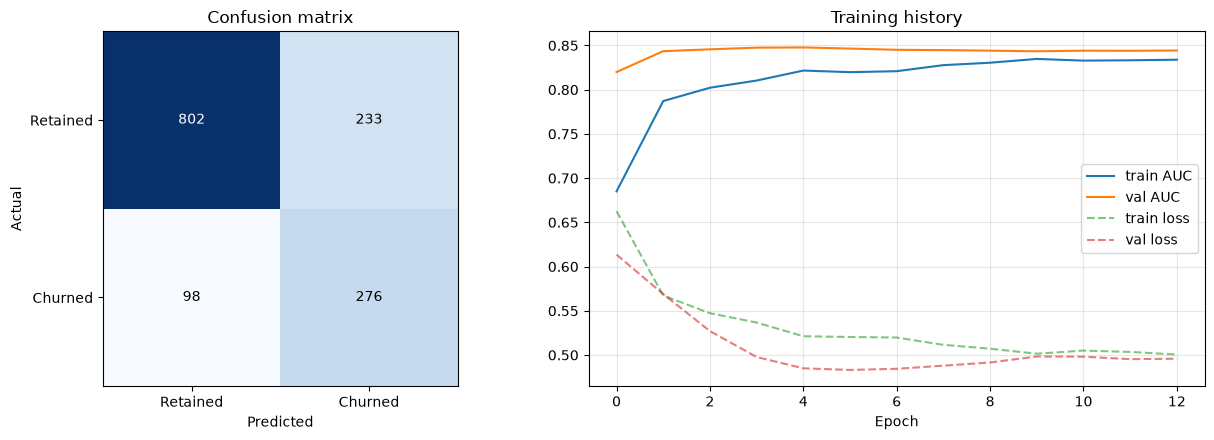

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1], ["Retained", "Churned"]); axes[0].set_yticks([0, 1], ["Retained", "Churned"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual"); axes[0].set_title("Confusion matrix")
axes[1].plot(history.history["auc"], label="train AUC")
axes[1].plot(history.history["val_auc"], label="val AUC")
axes[1].plot(history.history["loss"], "--", alpha=0.6, label="train loss")
axes[1].plot(history.history["val_loss"], "--", alpha=0.6, label="val loss")
axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_title("Training history")
plt.tight_layout(); plt.show()

## Reading the result

ROC AUC ≈ 0.85 sits at the top of what published work reports for this dataset — Telco
is small and noisy, and no amount of architecture buys much past that ceiling. The
class-weighted training deliberately trades precision for recall (catching a churner is
worth more than a false alarm — a retention offer is cheap, a lost subscriber is not);
moving the 0.5 threshold moves that trade.

What transfers from here to a production-scale problem is exactly what this notebook
walked through: the funnel (the same code, unchanged, at any width), the per-group
encoding, and the branch-per-family architecture (branch widths scale with each
family's signal). The reusable pieces live in `src/model_forge/churn/`; the same run is
scriptable as `python -m model_forge.churn.train`.